In [6]:
#Installing Libraries
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl joblib


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     -- ------------------------------------- 0.6/8.2 MB 11.5 MB/s eta 0:00:01
     ---- ----------------------------------- 0.9/8.2 MB 9.9 MB/s eta 0:00:01
     ----- ---------------------------------- 1.2/8.2 MB 8.5 MB/s eta 0:00:01
     ------ --------------------------------- 1.4/8.2 MB 7.6 MB/s eta 0:00:01
     -------- ------------------------------- 1.7/8.2 MB 7.1 MB/s eta 0:00:01
     --------- ------------------------------ 1.9/8.2 MB 6.8 MB/s eta 0:00:01
     ---------- ----------------------------- 2.2/8.2 MB 6.6 MB/s eta 0:00:01
     ----------- ---------------------------- 2.4/8.2 MB 6.3 MB/s eta 0:00:01
     ------------ --------------------------- 2.6/8.2 MB 6.2 MB/s eta 0:00:01
     ------------- -------------------------- 2.9/8.2 MB 6.1 MB/s eta 0:00:01
     --------------- ------------------------ 3.1/8.2 MB 6.0 MB/s eta 0:00:01
     ---------------- ----------------------- 3.3/8.2 MB 5.9 MB/s eta

In [15]:
#Importing Libraries & Data Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# Define the path to the Excel file
file_path = r"Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = "vw_ChurnData"

# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name = sheet_name)

# Display the first few rows of the fetched data
print(data.head())

  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   12052-PUN  Female   33      No          Punjab                   11   
1   12069-UTT  Female   30     Yes   Uttar Pradesh                   10   
2   12079-MAH  Female   73     Yes     Maharashtra                    2   
3   12112-MAD  Female   27      No  Madhya Pradesh                   14   
4   12118-TAM  Female   23      No      Tamil Nadu                    7   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                31        NaN           Yes            Yes  ...   
1                14     Deal 4           Yes             No  ...   
2                 4        NaN           Yes             No  ...   
3                 4     Deal 5           Yes             No  ...   
4                 3     Deal 2           Yes            Yes  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal     115.000000   7396.149902           0.0   
1  Bank Wi

In [8]:
#Data Procwssing

# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis = 1)

# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed' : 0, 'Churned' : 1})

# Split data into features and target
X = data.drop('Customer_Status', axis = 1)
y = data['Customer_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [9]:
# Train Random Forest Model
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Confusion Matrix:
[[786  54]
 [146 216]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       840
           1       0.80      0.60      0.68       362

    accuracy                           0.83      1202
   macro avg       0.82      0.77      0.79      1202
weighted avg       0.83      0.83      0.83      1202



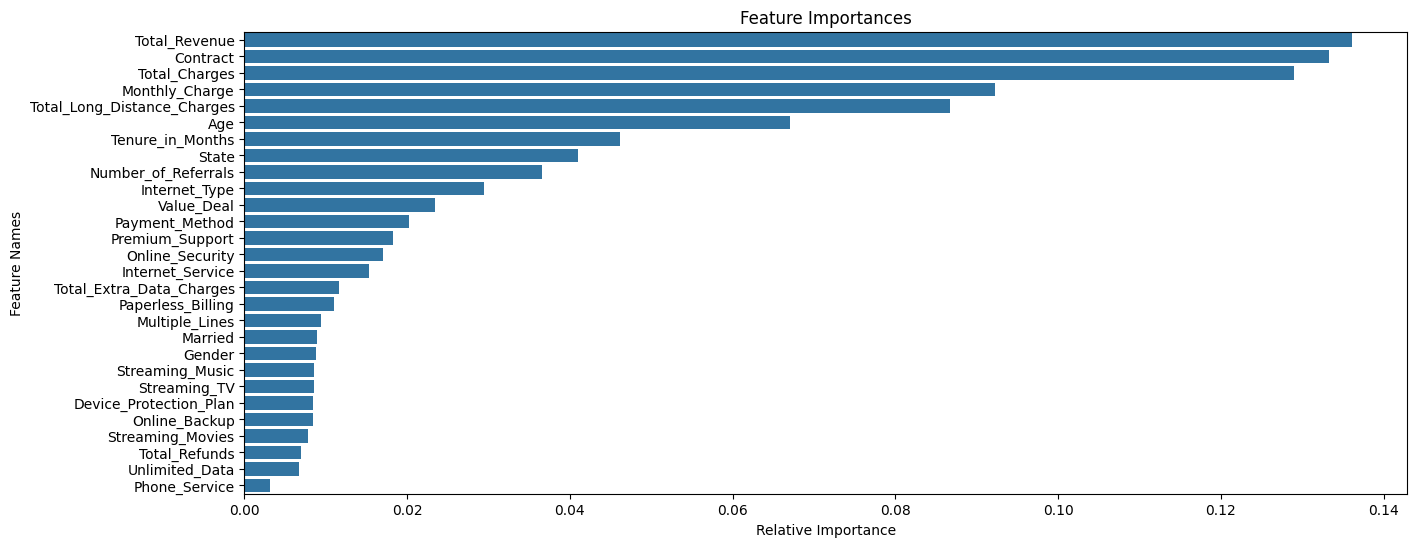

In [16]:
# Evaluate Model
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize = (15, 6))
sns.barplot( x= importances[indices], y = X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

In [17]:
# Use Model for Prediction on New Data
# Define the path to the Joiner Data Excel file
file_path = r"Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_JoinData'

# Read the data from the specified sheet into a pandas DataFrame
new_data = pd.read_excel(file_path, sheet_name = sheet_name)

# Display the first few rows of the fetched data
print(new_data.head())

# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

# Encode categorical variables using the saved label encoders
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

# Save the results
original_data.to_csv(r"Predictions.csv", index=False)


  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   12056-WES    Male   27      No    West Bengal                    2   
1   12136-RAJ  Female   25     Yes      Rajasthan                    2   
2   12257-ASS  Female   39      No          Assam                    9   
3   23078-UTT  Female   57     Yes  Uttar Pradesh                    3   
4   23148-CHH  Female   74     Yes   Chhattisgarh                    4   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                20        NaN           Yes             No  ...   
1                35        NaN           Yes             No  ...   
2                 1        NaN           Yes             No  ...   
3                24        NaN           Yes             No  ...   
4                 9     Deal 5           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      90.400002    268.450012           0.0   
1  Bank Withdraw